In [ ]:
import pandas as pd
df = pd.read_csv('./data/ab_test_results_aggregated_views_clicks_3.csv')
print(df.head())

   user_id    group  views  clicks
0        1  control    3.0     0.0
1        2  control    2.0     0.0
2        3  control    2.0     0.0
3        4  control    2.0     0.0
4        5  control    5.0     0.0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  90000 non-null  int64  
 1   group    90000 non-null  object 
 2   views    90000 non-null  float64
 3   clicks   90000 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.7+ MB


,user_id,views,clicks
count,90000.000000,90000.000000,90000.000000
mean,45000.500000,5.011522,0.278367
std,25980.906451,5.899868,0.612277
min,1.000000,1.000000,0.000000
25%,22500.750000,2.000000,0.000000
50%,45000.500000,3.000000,0.000000
75%,67500.250000,6.000000,0.000000
max,90000.000000,204.000000,14.000000


In [ ]:
# check balance
df.groupby('group')['user_id'].count()

group
control    45000
test       45000
Name: user_id, dtype: int64

array([<Axes: title={'center': 'control'}>,
       <Axes: title={'center': 'test'}>], dtype=object)

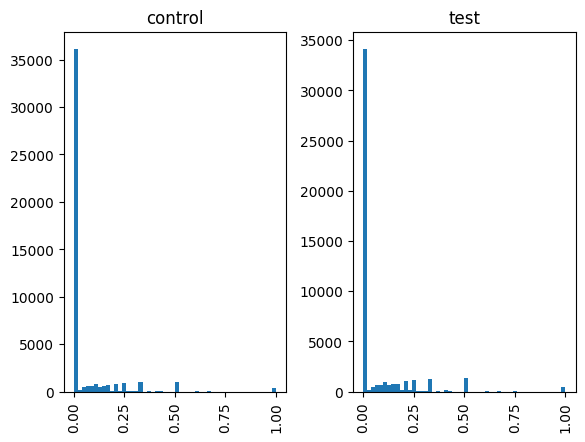

In [8]:
# distribution
df['ctr'] = df['clicks'] / df['views']
df['ctr'].hist(by=df['group'],bins=50)

<Axes: xlabel='ctr', ylabel='Density'>

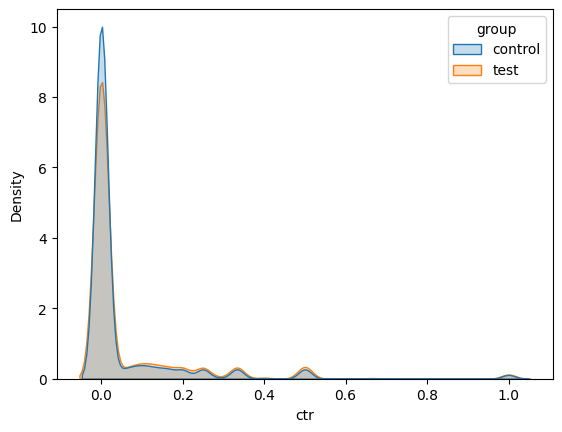

In [15]:
import seaborn as sns
sns.kdeplot(
    data=df,
    x="ctr",
    hue="group",
    fill=True
)

<Axes: xlabel='group', ylabel='views'>

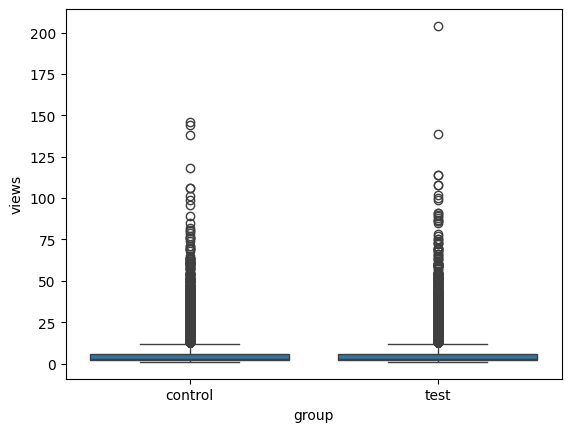

In [10]:
import seaborn as sns
sns.boxplot(x='group',y='views',data=df)

In [ ]:
df.groupby('group')['ctr'].mean()

group
control    0.048464
test       0.062712
Name: ctr, dtype: float64

## bootstrap method

In [36]:
import numpy as np
def bootstrap_ctr_diff(df,group_col='group', clicks_col='clicks', views_col='views', n_boost=5000):
    control = df[df[group_col] == 'control']
    treatment = df[df[group_col] == 'test']
    diffs = []
    for _ in range(n_boost):
        c = control.sample(len(control), replace=True)
        t = treatment.sample(len(treatment), replace=True)
        c_ctr = c[clicks_col].sum() / c[views_col].sum()
        t_ctr = t[clicks_col].sum() / t[views_col].sum()
        diffs.append(t_ctr - c_ctr)
    lower,upper = np.percentile(diffs, [2.5, 97.5])
    p_value = max(np.mean(np.array(diffs) <= 0), 1/len(np.array(diffs)))

    return np.mean(diffs), lower, upper, p_value, diffs

In [37]:
result = bootstrap_ctr_diff(df)
print(result[3])

0.0002


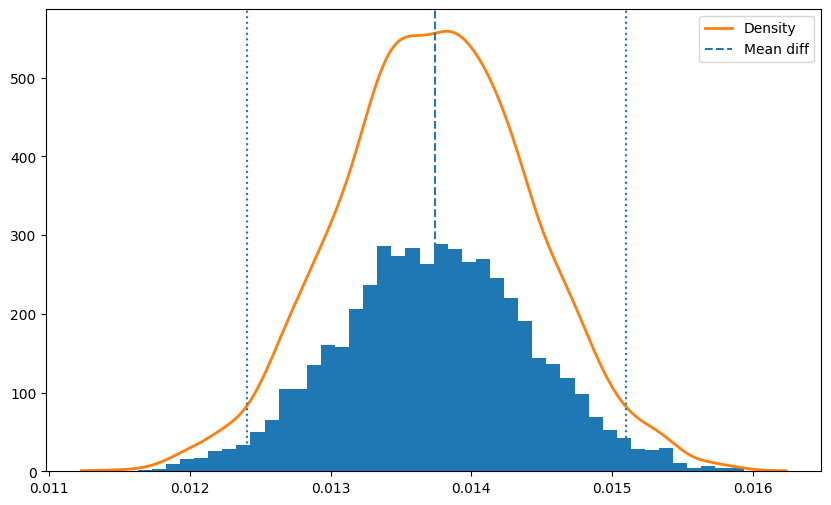

In [28]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
bootstrap_ctr_diff = np.array(result[4])
plt.figure(figsize=(10,6))
plt.hist(bootstrap_ctr_diff, bins=50)
x = np.linspace(bootstrap_ctr_diff.min(), bootstrap_ctr_diff.max(), 500)
kde = gaussian_kde(bootstrap_ctr_diff)
plt.plot(x, kde(x), linewidth=2, label='Density')
plt.axvline(bootstrap_ctr_diff.mean(), linestyle='--', label='Mean diff')
lower = result[1]
upper = result[2]
plt.axvline(lower, linestyle=':')
plt.axvline(upper, linestyle=':')
plt.legend()
plt.show()

The bootstrap distribution suggests a statistically robust positive treatment effect, with nearly all resampled estimates showing CTR improvement over control. The confidence interval excludes zero, indicating the observed lift is unlikely to be due to random variation alone.

## Z Test

In [38]:
# check n * p = 4500 * 0.05 = 225 large enough to satify CLT condition for z test
from statsmodels.stats.proportion import proportions_ztest
summary = df.groupby('group')[['clicks','views']].sum().reset_index()
summary['ctr'] = summary['clicks'] / summary['views']
clicks = np.array(summary['clicks'])
views = np.array(summary['views'])
z_stat, p_value = proportions_ztest(clicks, views)
print(f"Z-statistic: {z_stat}, P-value: {p_value}")

Z-statistic: -20.16425842618982, P-value: 2.017485494545516e-90


In [39]:
def manual_ctr_ztest(df,group_col='group', clicks_col='clicks', views_col='views'):
    summary = df.groupby(group_col)[[clicks_col, views_col]].sum().reset_index()
    summary['ctr'] = summary[clicks_col] / summary[views_col]
    p1 = summary.loc[summary[group_col] == 'test', 'ctr'].values[0]
    p2 = summary.loc[summary[group_col] == 'control', 'ctr'].values[0]
    n1 = summary.loc[summary[group_col] == 'test', views_col].values[0]
    n2 = summary.loc[summary[group_col] == 'control', views_col].values[0]
    p_pool = (summary.loc[summary[group_col] == 'test', clicks_col].values[0] + 
              summary.loc[summary[group_col] == 'control', clicks_col].values[0]) / (n1 + n2)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z_stat = (p1 - p2) / se_pool
    from scipy.stats import norm
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    return z_stat, p_value

In [40]:
result = manual_ctr_ztest(df)
print(f"Z-statistic: {result[0]}, P-value: {result[1]}")

Z-statistic: 20.16425842618982, P-value: 0.0
